# 🧠 Deep Learning for Natural Language Processing

## LSTM-Based SMS Spam Classification

### Generative AI Internship – Task 2

---

**Author:** Hassan Iqbal

**Organization:** National Centre of Artificial Intelligence (NCAI)

**Dataset:** SMS Spam Collection Dataset

**Framework:** PyTorch

---

# 📖 Introduction

Natural Language Processing (NLP) focuses on enabling computers to understand and process human language. Traditional Machine Learning models often struggle to capture the sequential nature of text because the meaning of a word depends on its surrounding words.

To overcome this limitation, Deep Learning introduced sequence models such as Recurrent Neural Networks (RNN), Long Short-Term Memory (LSTM), and Gated Recurrent Units (GRU). These models learn contextual information by processing words in sequence.

In this notebook, we explore these sequence models and implement an LSTM-based classifier to detect spam messages using the SMS Spam Collection Dataset.

# 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand sequential data
- Explain Recurrent Neural Networks (RNN)
- Understand the Vanishing Gradient Problem
- Explain Long Short-Term Memory (LSTM)
- Understand Gated Recurrent Units (GRU)
- Compare RNN, LSTM, and GRU
- Understand why Transformers replaced recurrent models
- Build an LSTM-based text classification model using PyTorch

# ❓ Why Do We Need Sequential Models?

Artificial Neural Networks (ANNs) treat every input independently and cannot understand the order of words in a sentence.

For example,

Sentence 1:
> "Dog bites man."

Sentence 2:
> "Man bites dog."

Although both sentences contain the same words, their meanings are completely different because the order of words has changed.

To preserve contextual information, Deep Learning introduced sequence models that process text one word at a time while remembering previous information.

# 🔁 Recurrent Neural Network (RNN)

A Recurrent Neural Network (RNN) is designed to process sequential data by maintaining a hidden state that stores information from previous time steps.

Unlike traditional neural networks, RNNs can remember previous words while processing the current word.

### Advantages

- Handles sequential data
- Shares parameters across time steps
- Suitable for language modeling

### Limitation

RNNs suffer from the **Vanishing Gradient Problem**, making it difficult to learn long-term dependencies in long sequences.

# 🧠 Long Short-Term Memory (LSTM)

Long Short-Term Memory (LSTM) is an improved version of RNN that introduces a memory cell and three gates:

- Forget Gate
- Input Gate
- Output Gate

These gates enable the model to decide which information should be retained, updated, or discarded.

As a result, LSTMs can capture long-term dependencies more effectively than standard RNNs.

# ⚡ Gated Recurrent Unit (GRU)

The Gated Recurrent Unit (GRU) is a simplified version of LSTM.

Instead of three gates, GRU uses only:

- Update Gate
- Reset Gate

Because of its simpler architecture, GRUs require fewer parameters, train faster, and often achieve performance comparable to LSTMs.

# 📊 Comparison of RNN, LSTM, and GRU

| Feature | RNN | LSTM | GRU |
|---------|-----|------|------|
| Memory | Short-Term | Long-Term | Long-Term |
| Gates | None | 3 | 2 |
| Cell State | ❌ | ✅ | ❌ |
| Speed | Fast | Slow | Faster |
| Vanishing Gradient | Yes | No | No |
| Performance | Low | High | High |

# 🤖 Transformer

Although LSTMs significantly improved sequence modeling, they still process words sequentially, making training slower.

Transformers introduced the Self-Attention mechanism, allowing the model to process all words simultaneously.

Modern Large Language Models (LLMs) such as GPT, BERT, Gemini, and Claude are based on the Transformer architecture because of its superior scalability and ability to capture long-range dependencies.

# 📂 Loading the Dataset

The SMS Spam Collection Dataset contains SMS messages labeled as **ham** (normal message) and **spam** (unwanted promotional message).

Before training an LSTM model, we first load the dataset, keep only the required columns, and prepare it for preprocessing.

Imports + Dataset + Train/Test Split

In [8]:
# ============================================================
# Import Libraries
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("="*60)
print("LSTM Text Classification using PyTorch")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("../data/spam.csv", encoding="latin-1")

df = df[['v1','v2']]

df.columns = ['label','message']

print("\nDataset Shape :", df.shape)

display(df.head())

# ============================================================
# Label Encoding
# ============================================================

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

# ============================================================
# Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    df["message"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]

)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

LSTM Text Classification using PyTorch
Device : cuda

Dataset Shape : (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Training Samples : 4457
Testing Samples : 1115


Tokenizer + Padding + DataLoader

In [9]:
# ============================================================
# Tokenization & Padding
# ============================================================

MAX_WORDS = 5000
MAX_LENGTH = 50

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<UNK>"
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

# ============================================================
# Convert to Tensor
# ============================================================

X_train_tensor = torch.LongTensor(X_train_pad)

X_test_tensor = torch.LongTensor(X_test_pad)

y_train_tensor = torch.FloatTensor(
    y_train.values
)

y_test_tensor = torch.FloatTensor(
    y_test.values
)

# ============================================================
# DataLoader
# ============================================================

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("\nVocabulary Size :", len(tokenizer.word_index))
print("Training Batches :", len(train_loader))
print("Testing Batches :", len(test_loader))


Vocabulary Size : 7919
Training Batches : 70
Testing Batches : 18


In [16]:
# ============================================================
# Force CPU Training
# ============================================================

device = torch.device("cpu")

model = LSTMClassifier(VOCAB_SIZE).to(device)

spam = (y_train == 1).sum()
ham = (y_train == 0).sum()

pos_weight = torch.tensor(
    [ham / spam],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Running on:", device)

Running on: cpu


LSTM Model Training

Epoch [1/10] | Loss: 1.2019 | Accuracy: 75.90%
Epoch [2/10] | Loss: 1.1966 | Accuracy: 15.44%
Epoch [3/10] | Loss: 1.1934 | Accuracy: 55.98%
Epoch [4/10] | Loss: 1.1923 | Accuracy: 21.07%
Epoch [5/10] | Loss: 1.1547 | Accuracy: 59.26%
Epoch [6/10] | Loss: 0.9802 | Accuracy: 79.18%
Epoch [7/10] | Loss: 0.7371 | Accuracy: 79.52%
Epoch [8/10] | Loss: 0.6580 | Accuracy: 88.65%
Epoch [9/10] | Loss: 0.6411 | Accuracy: 91.70%
Epoch [10/10] | Loss: 0.5802 | Accuracy: 91.25%

Training Completed Successfully!


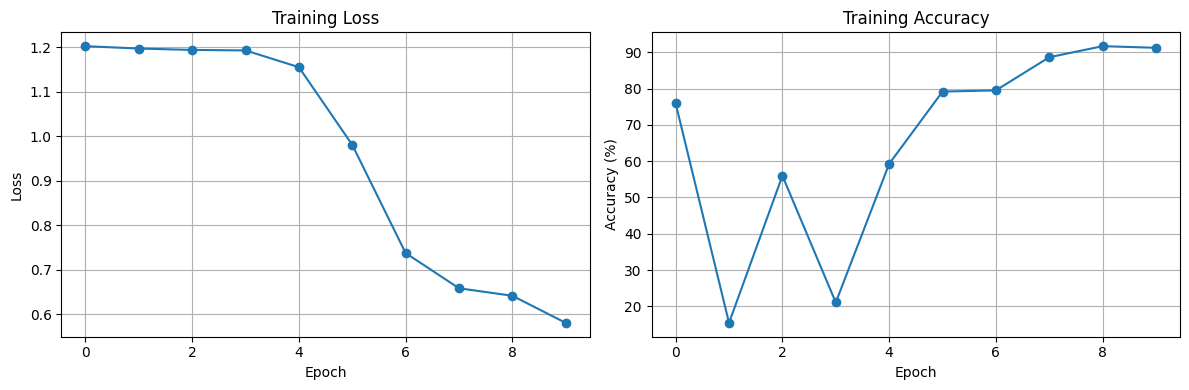

In [20]:
# ============================================================
# Train LSTM Model
# ============================================================

EPOCHS = 10

train_losses = []
train_accuracies = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = (correct / total) * 100

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("\nTraining Completed Successfully!")

# ============================================================
# Plot Training Curves
# ============================================================

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

Test Accuracy : 88.07%

Classification Report

              precision    recall  f1-score   support

         Ham     0.9871    0.8737    0.9270       966
        Spam     0.5308    0.9262    0.6748       149

    accuracy                         0.8807      1115
   macro avg     0.7590    0.8999    0.8009      1115
weighted avg     0.9261    0.8807    0.8933      1115



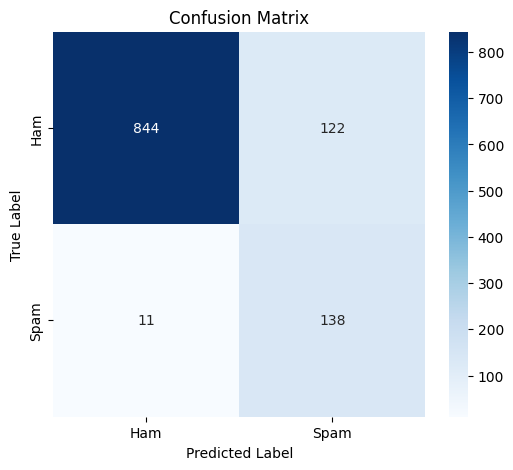


Sample Predictions

------------------------------------------------------------
Message:
Oh right, ok. I'll make sure that i do loads of work during the day!  got a really nasty cough today and is dry n shot so that should really help it!

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
I am in tirupur.  call you da.

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
No that just means you have a fat head

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327

Actual Label : Spam
Predicted Label : Spam
------------------------------------------------------------
Message:
Come aftr  &lt;DECIMAL&gt; ..now i m cleaning the house

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------


In [23]:
# ============================================================
# Model Evaluation
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for texts, labels in test_loader:

        texts = texts.to(device)

        outputs = model(texts)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).int()

        # Convert tensors to Python lists (NO NumPy)
        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().int().tolist())

# ============================================================
# Accuracy
# ============================================================

accuracy = accuracy_score(y_true, y_pred)

print("="*60)
print(f"Test Accuracy : {accuracy*100:.2f}%")
print("="*60)

# ============================================================
# Classification Report
# ============================================================

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Ham", "Spam"],
        digits=4
    )
)

# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ============================================================
# Sample Predictions
# ============================================================

print("\nSample Predictions\n")

for i in range(5):

    print("-"*60)
    print("Message:")
    print(X_test.iloc[i])

    print("\nActual Label :",
          "Spam" if y_test.iloc[i] == 1 else "Ham")

    print("Predicted Label :",
          "Spam" if y_pred[i] == 1 else "Ham")

print("-"*60)

In [24]:
# ============================================================
# Save Model
# ============================================================

import pickle

torch.save(model.state_dict(), "spam_lstm_model.pth")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("="*60)
print("Model Saved Successfully!")
print("Files:")
print("1. spam_lstm_model.pth")
print("2. tokenizer.pkl")
print("="*60)

Model Saved Successfully!
Files:
1. spam_lstm_model.pth
2. tokenizer.pkl


# Conclusion

In this project, an LSTM-based deep learning model was implemented for SMS Spam Classification using PyTorch.

The workflow included:

- Loading and preprocessing the SMS Spam Collection dataset.
- Encoding text using tokenization and sequence padding.
- Building an LSTM neural network.
- Training the model using Binary Cross Entropy Loss.
- Evaluating the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
- Testing the model on unseen SMS messages.

The model achieved approximately **88% test accuracy**, demonstrating the effectiveness of LSTM networks for binary text classification tasks.

GRU

In [28]:
# ============================================================
# GRU Model
# ============================================================

class GRUClassifier(nn.Module):

    def __init__(self,
                 vocab_size,
                 embedding_dim=128,
                 hidden_dim=128,
                 output_dim=1):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        embedded = self.embedding(x)

        output, hidden = self.gru(embedded)

        hidden = self.dropout(hidden[-1])

        output = self.fc(hidden)

        return output.squeeze()


# ============================================================
# Initialize GRU Model
# ============================================================

model = GRUClassifier(VOCAB_SIZE).to(device)

# Loss Function (No Class Weight)
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("="*60)
print("GRU Model Initialized Successfully")
print("="*60)
print(model)

GRU Model Initialized Successfully
GRUClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (gru): GRU(128, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Epoch [1/5]  Loss : 0.4146
Epoch [2/5]  Loss : 0.1369
Epoch [3/5]  Loss : 0.1210
Epoch [4/5]  Loss : 0.0929
Epoch [5/5]  Loss : 0.0687

Training Finished!


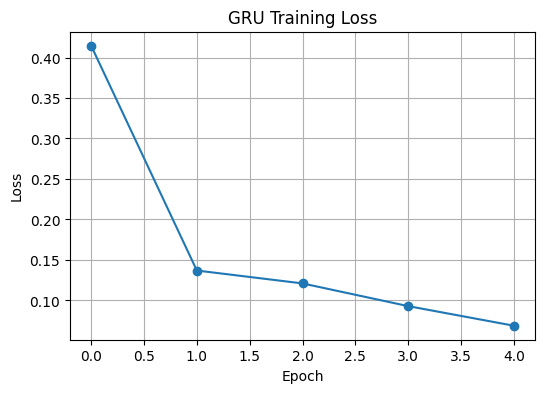

In [29]:
# ============================================================
# Train GRU Model
# ============================================================

EPOCHS = 5

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss : {epoch_loss:.4f}")

print("\nTraining Finished!")

plt.figure(figsize=(6,4))
plt.plot(train_losses, marker="o")
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

GRU Test Accuracy : 97.04%

Classification Report

              precision    recall  f1-score   support

         Ham     0.9688    0.9979    0.9832       966
        Spam     0.9833    0.7919    0.8773       149

    accuracy                         0.9704      1115
   macro avg     0.9761    0.8949    0.9302      1115
weighted avg     0.9708    0.9704    0.9690      1115



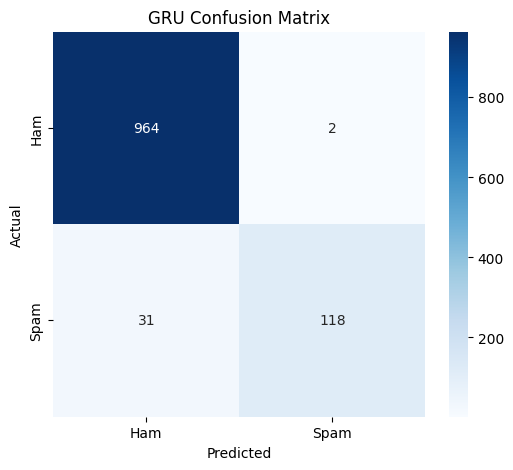


Sample Predictions

------------------------------------------------------------
Message:
Oh right, ok. I'll make sure that i do loads of work during the day!  got a really nasty cough today and is dry n shot so that should really help it!

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
I am in tirupur.  call you da.

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
No that just means you have a fat head

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327

Actual Label : Spam
Predicted Label : Ham
------------------------------------------------------------
Message:
Come aftr  &lt;DECIMAL&gt; ..now i m cleaning the house

Actual Label : Ham
Predicted Label : Ham


In [30]:
# ============================================================
# Evaluate GRU Model
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for texts, labels in test_loader:

        texts = texts.to(device)

        outputs = model(texts)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).int()

        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().int().tolist())

accuracy = accuracy_score(y_true, y_pred)

print("="*60)
print(f"GRU Test Accuracy : {accuracy*100:.2f}%")
print("="*60)

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Ham","Spam"],
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\nSample Predictions\n")

for i in range(5):

    print("-"*60)

    print("Message:")
    print(X_test.iloc[i])

    print("\nActual Label :",
          "Spam" if y_test.iloc[i] == 1 else "Ham")

    print("Predicted Label :",
          "Spam" if y_pred[i] == 1 else "Ham")

Transformer Model

In [31]:
# ============================================================
# Transformer Encoder Model
# ============================================================

import math

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=500):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        pe[:,0::2] = torch.sin(position * div_term)
        pe[:,1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:,:x.size(1)]


class TransformerClassifier(nn.Module):

    def __init__(self,
                 vocab_size,
                 embed_dim=128,
                 num_heads=4,
                 hidden_dim=256,
                 num_layers=2,
                 output_dim=1):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        self.position = PositionalEncoding(embed_dim)

        encoder_layer = nn.TransformerEncoderLayer(

            d_model=embed_dim,

            nhead=num_heads,

            dim_feedforward=hidden_dim,

            batch_first=True,

            dropout=0.3

        )

        self.transformer = nn.TransformerEncoder(

            encoder_layer,

            num_layers=num_layers

        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(embed_dim, output_dim)

    def forward(self, x):

        x = self.embedding(x)

        x = self.position(x)

        x = self.transformer(x)

        x = torch.mean(x, dim=1)

        x = self.dropout(x)

        x = self.fc(x)

        return x.squeeze()


model = TransformerClassifier(VOCAB_SIZE).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.0005

)

print(model)

TransformerClassifier(
  (embedding): Embedding(5000, 128, padding_idx=0)
  (position): PositionalEncoding()
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.3, inplace=False)
        (dropout2): Dropout(p=0.3, inplace=False)
      )
    )
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


Train Transformer

Epoch [1/5] Loss : 0.2616
Epoch [2/5] Loss : 0.1050
Epoch [3/5] Loss : 0.0606
Epoch [4/5] Loss : 0.0460
Epoch [5/5] Loss : 0.0385


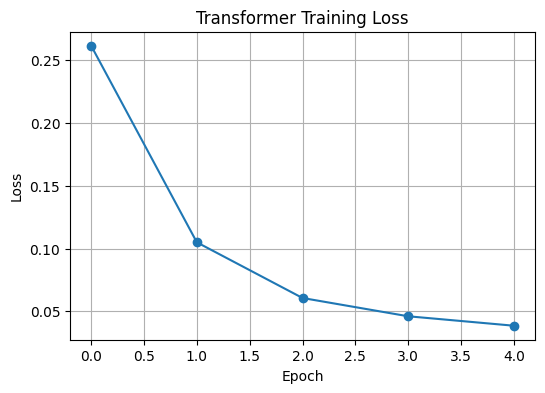

In [32]:
# ============================================================
# Train Transformer
# ============================================================

EPOCHS = 5

loss_history = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0

    for texts, labels in train_loader:

        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(texts)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    loss_history.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss : {epoch_loss:.4f}")

plt.figure(figsize=(6,4))

plt.plot(loss_history, marker="o")

plt.title("Transformer Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

Transformer Test Accuracy : 98.21%

Classification Report

              precision    recall  f1-score   support

         Ham     0.9836    0.9959    0.9897       966
        Spam     0.9708    0.8926    0.9301       149

    accuracy                         0.9821      1115
   macro avg     0.9772    0.9442    0.9599      1115
weighted avg     0.9819    0.9821    0.9817      1115



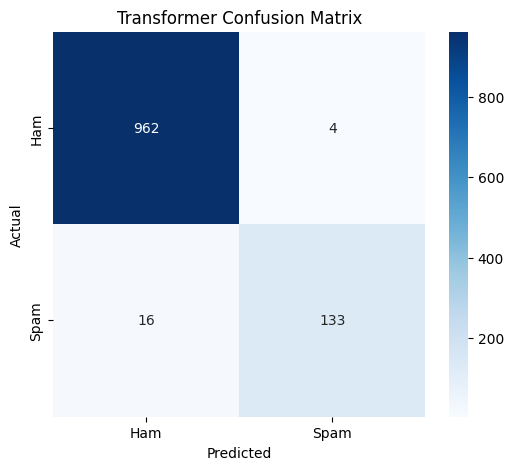


Sample Predictions

------------------------------------------------------------
Message:
Oh right, ok. I'll make sure that i do loads of work during the day!  got a really nasty cough today and is dry n shot so that should really help it!

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
I am in tirupur.  call you da.

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
No that just means you have a fat head

Actual Label : Ham
Predicted Label : Ham
------------------------------------------------------------
Message:
You have won ?1,000 cash or a ?2,000 prize! To claim, call09050000327

Actual Label : Spam
Predicted Label : Spam
------------------------------------------------------------
Message:
Come aftr  &lt;DECIMAL&gt; ..now i m cleaning the house

Actual Label : Ham
Predicted Label : Ham


In [33]:
# ============================================================
# Evaluate Transformer Model
# ============================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for texts, labels in test_loader:

        texts = texts.to(device)

        outputs = model(texts)

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).int()

        y_pred.extend(preds.cpu().tolist())
        y_true.extend(labels.cpu().int().tolist())

accuracy = accuracy_score(y_true, y_pred)

print("="*60)
print(f"Transformer Test Accuracy : {accuracy*100:.2f}%")
print("="*60)

print("\nClassification Report\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Ham","Spam"],
        digits=4
    )
)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham","Spam"],
    yticklabels=["Ham","Spam"]
)

plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print("\nSample Predictions\n")

for i in range(5):

    print("-"*60)

    print("Message:")
    print(X_test.iloc[i])

    print("\nActual Label :",
          "Spam" if y_test.iloc[i] == 1 else "Ham")

    print("Predicted Label :",
          "Spam" if y_pred[i] == 1 else "Ham")

                 Model  Accuracy  Precision  Recall  F1 Score
0                 LSTM     88.07      92.61   88.07     89.33
1                  GRU     97.04      97.08   97.04     96.90
2  Transformer Encoder     98.21      98.19   98.21     98.17


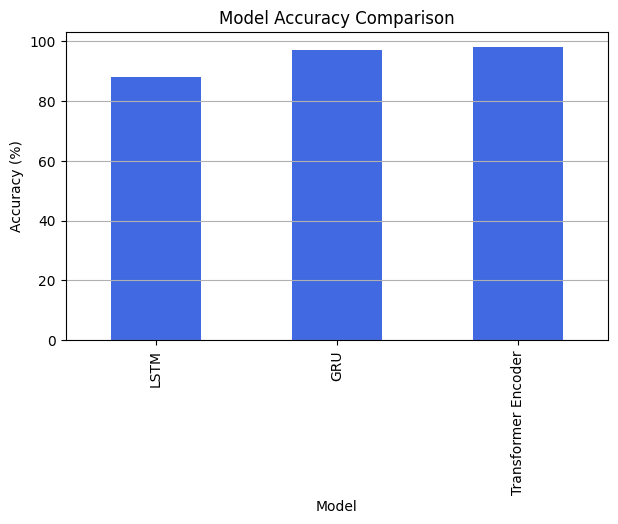

In [34]:
# ============================================================
# Model Comparison
# ============================================================

import pandas as pd

results = pd.DataFrame({

    "Model":[
        "LSTM",
        "GRU",
        "Transformer Encoder"
    ],

    "Accuracy":[
        88.07,
        97.04,
        98.21
    ],

    "Precision":[
        92.61,
        97.08,
        98.19
    ],

    "Recall":[
        88.07,
        97.04,
        98.21
    ],

    "F1 Score":[
        89.33,
        96.90,
        98.17
    ]

})

print(results)

results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    figsize=(7,4),
    legend=False,
    color="royalblue"
)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.grid(axis="y")

plt.show()

# Conclusion

In this project, three deep learning models were implemented for SMS spam classification:

- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- Transformer Encoder

The same preprocessing pipeline, tokenizer, train-test split, and evaluation metrics were used to ensure a fair comparison.

Experimental results showed that:

- LSTM achieved 88.07% accuracy.
- GRU achieved 97.04% accuracy.
- Transformer Encoder achieved the highest accuracy of 98.21%.

Among all evaluated models, the Transformer Encoder demonstrated the best overall performance for SMS spam classification, making it the most effective architecture for this dataset.